# Adult Income Classification Project

## Machine Learning Classification Models
- Logistic Regression
- Decision Tree
- SVC
- KNN

## Technologies Used
- Python
- Pandas
- Matplotlib
- Scikit-learn
- FastAPI
- Streamlit

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import joblib

In [3]:
df = pd.read_csv(r"H:\python\python 3.12.9\adult-income-classification\adult.csv")

In [4]:
df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [5]:
df.shape

(48842, 15)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       48842 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   48842 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


In [13]:
df.isnull().sum()

age                0
workclass          0
fnlwgt             0
education          0
educational-num    0
marital-status     0
occupation         0
relationship       0
race               0
gender             0
capital-gain       0
capital-loss       0
hours-per-week     0
native-country     0
income             0
dtype: int64

In [8]:
df = df.replace(" ?", np.nan)

In [15]:
df.isnull().sum()

age                0
workclass          0
fnlwgt             0
education          0
educational-num    0
marital-status     0
occupation         0
relationship       0
race               0
gender             0
capital-gain       0
capital-loss       0
hours-per-week     0
native-country     0
income             0
dtype: int64

In [16]:
categorical_columns = df.select_dtypes(include='object').columns
numerical_columns = df.select_dtypes(exclude='object').columns

In [19]:
for col in categorical_columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

for col in numerical_columns:
    df[col].fillna(df[col].median(), inplace=True)

C:\Users\H A TRADERS\AppData\Local\Temp\ipykernel_2664\247240381.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)
C:\Users\H A TRADERS\AppData\Local\Temp\ipykernel_2664\247240381.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.



In [20]:
df.isnull().sum()

age                0
workclass          0
fnlwgt             0
education          0
educational-num    0
marital-status     0
occupation         0
relationship       0
race               0
gender             0
capital-gain       0
capital-loss       0
hours-per-week     0
native-country     0
income             0
dtype: int64

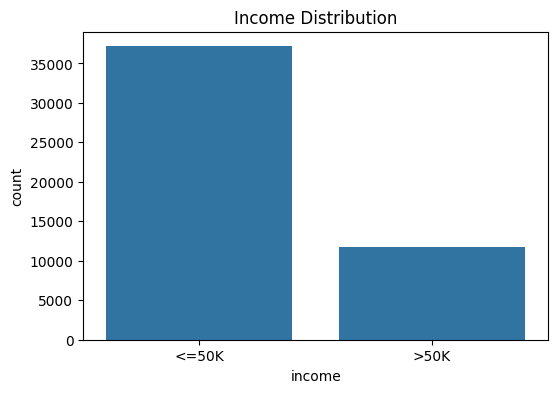

In [22]:
# INCOME DISTRIBUTION

plt.figure(figsize=(6,4))
sns.countplot(x='income', data=df)
plt.title("Income Distribution")
plt.show()

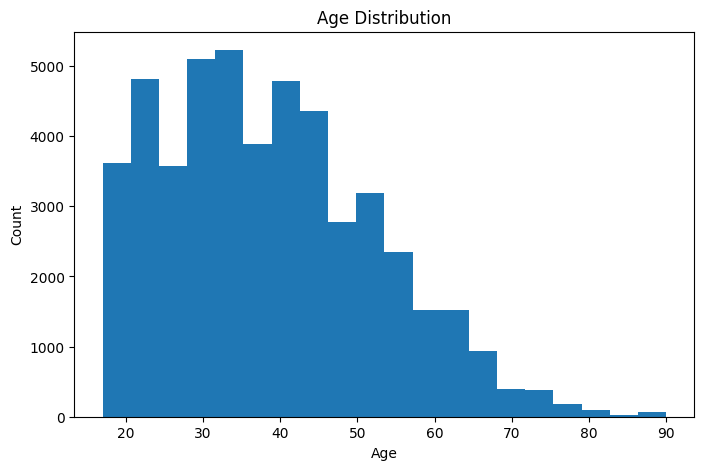

In [23]:
# AGE HISTOGRAM

plt.figure(figsize=(8,5))
plt.hist(df['age'], bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

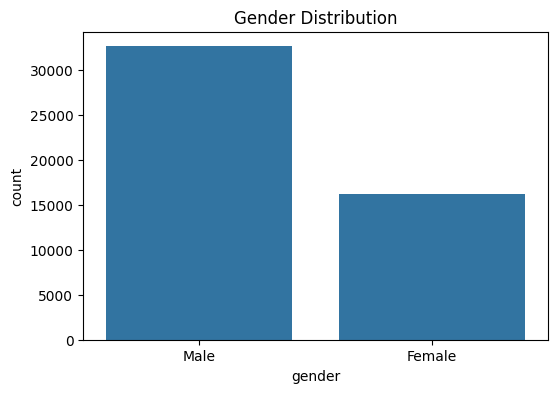

In [24]:
# GENDER DISTRIBUTION

plt.figure(figsize=(6,4))
sns.countplot(x='gender', data=df)
plt.title("Gender Distribution")
plt.show()

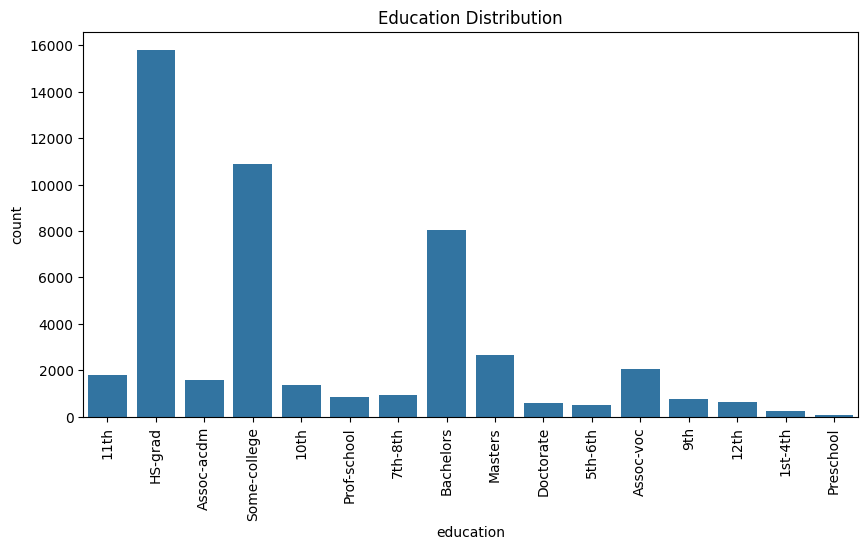

In [25]:
# EDUCATION DISTRIBUTION

plt.figure(figsize=(10,5))
sns.countplot(x='education', data=df)
plt.xticks(rotation=90)
plt.title("Education Distribution")
plt.show()

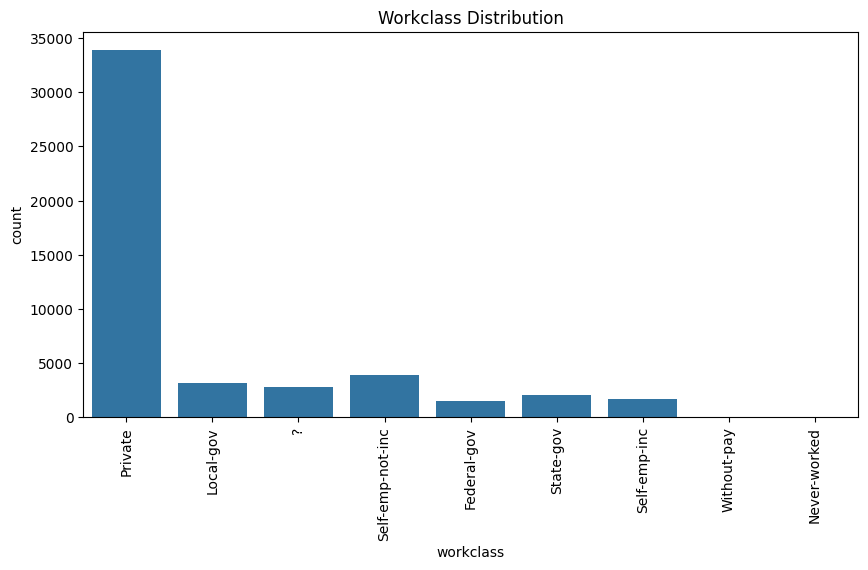

In [26]:
# WORKCLASS DISTRIBUTION

plt.figure(figsize=(10,5))
sns.countplot(x='workclass', data=df)
plt.xticks(rotation=90)
plt.title("Workclass Distribution")
plt.show()

In [27]:
# SPLIT FEATURES & TARGET

X = df.drop("income", axis=1)
y = df["income"]

In [28]:
# TRAIN TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [29]:
# PREPROCESSING PIPELINE

categorical_features = X.select_dtypes(include='object').columns
numerical_features = X.select_dtypes(exclude='object').columns

In [30]:
# COLUMN TRANSFORMER

preprocessor = ColumnTransformer(
    transformers=[
        (
            'cat',
            OneHotEncoder(handle_unknown='ignore'),
            categorical_features
        )
    ],
    remainder='passthrough'
)

In [31]:
# Logistic Regression
logistic_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000))
])

In [33]:
# Decision Tree

decision_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier())
])

In [34]:
# SVC

svc_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', SVC())
])

In [35]:
# KNN

knn_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', KNeighborsClassifier())
])

In [36]:
# TRAIN MODELS

models = {
    "Logistic Regression": logistic_pipeline,
    "Decision Tree": decision_pipeline,
    "SVC": svc_pipeline,
    "KNN": knn_pipeline
}

In [37]:
# TRAIN + ACCURACY

accuracy_results = {}

for name, model in models.items():

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    accuracy = accuracy_score(y_test, predictions)

    accuracy_results[name] = accuracy

    print(f"{name} Accuracy: {accuracy:.4f}")

H:\python\python 3.12.9\adult-income-classification\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression Accuracy: 0.8503
Decision Tree Accuracy: 0.8177
SVC Accuracy: 0.8034
KNN Accuracy: 0.7835


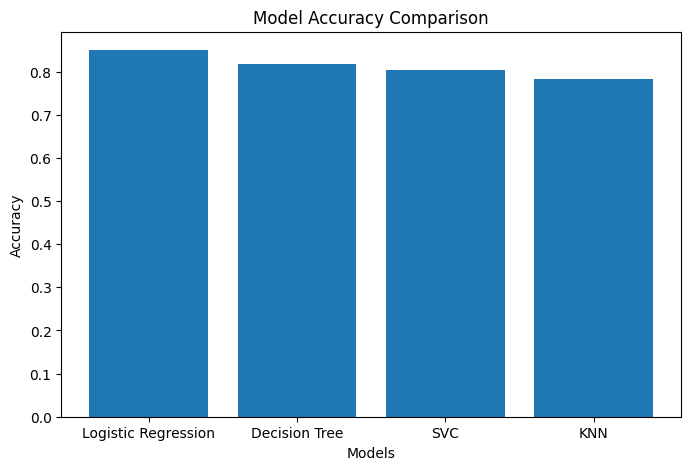

In [40]:
# ACCURACY COMPARISON PLOT

model_names = list(accuracy_results.keys())
accuracy_values = list(accuracy_results.values())

plt.figure(figsize=(8,5))
plt.bar(model_names, accuracy_values)

plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.show()

In [41]:
# BEST MODEL

best_model_name = max(accuracy_results, key=accuracy_results.get)

print("Best Model:", best_model_name)

Best Model: Logistic Regression


In [42]:
# SAVING BEST MODEL

best_model = models[best_model_name]

joblib.dump(
    best_model,
    r"H:\python\python 3.12.9\adult-income-classification\model.pkl"
)

['H:\\python\\python 3.12.9\\adult-income-classification\\model.pkl']

In [43]:
loaded_model = joblib.load(
    r"H:\python\python 3.12.9\adult-income-classification\model.pkl"
)

print("Model Loaded Successfully")

Model Loaded Successfully
